In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from src.shash_torch import Shash
import numpy as np
import torch

In [2]:
model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
#model_spec = 'cnn3d_3_layer/level=small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'

In [3]:
results = xr.open_dataset(f'results/predictions/{model_spec}/predictions.nc')

In [4]:
def add_shash_mean(ds):
    # pull parameters as torch tensors
    mu    = torch.from_numpy(ds["mu"].values)
    sigma = torch.from_numpy(ds["sigma"].values)
    gamma = torch.from_numpy(ds["gamma"].values)
    tau   = torch.from_numpy(ds["tau"].values)

    # build distribution
    params = torch.stack([mu, sigma, gamma, tau], dim=-1)
    sh = Shash(params)

    # compute true mean
    mean = sh.mean().numpy()

    # add to dataset
    ds["mean"] = xr.DataArray(
        mean,
        coords=ds["mu"].coords,
        dims=ds["mu"].dims,
    )

    return ds


In [5]:
results = add_shash_mean(results)

(array([  1.,   0.,   0.,   2.,   3.,   2.,   2.,   6.,   9.,  14.,  13.,
         28.,  38.,  63.,  66.,  79.,  94., 130., 151., 154., 171., 187.,
        206., 232., 219., 218., 211., 205., 182., 155., 143., 107.,  94.,
         59.,  41.,  38.,  26.,  20.,  10.,  11.,   8.,   6.,   4.,   1.,
          1.,   3.,   0.,   0.,   0.,   1.]),
 array([-0.81570113, -0.78175843, -0.74781573, -0.71387303, -0.67993033,
        -0.64598757, -0.61204487, -0.57810217, -0.54415947, -0.51021677,
        -0.47627407, -0.44233134, -0.40838864, -0.37444595, -0.34050325,
        -0.30656052, -0.27261782, -0.23867512, -0.2047324 , -0.1707897 ,
        -0.13684699, -0.10290429, -0.06896158, -0.03501888, -0.00107617,
         0.03286654,  0.06680924,  0.10075195,  0.13469465,  0.16863737,
         0.20258006,  0.23652278,  0.27046549,  0.30440819,  0.33835089,
         0.37229359,  0.40623632,  0.44017902,  0.47412172,  0.50806445,
         0.54200715,  0.57594985,  0.60989255,  0.64383525,  0.67777795,
 

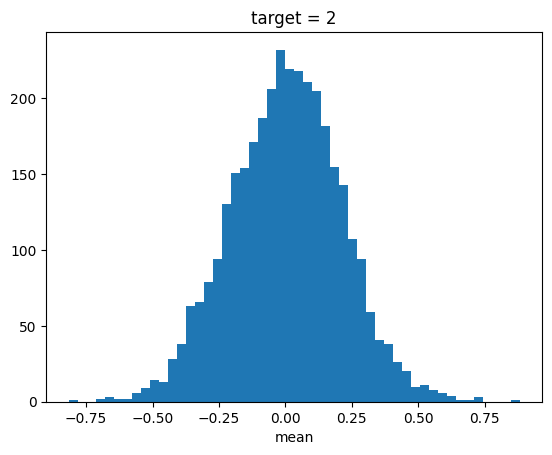

In [6]:
results['mean'].sel(target = 2).plot.hist(bins = 50)

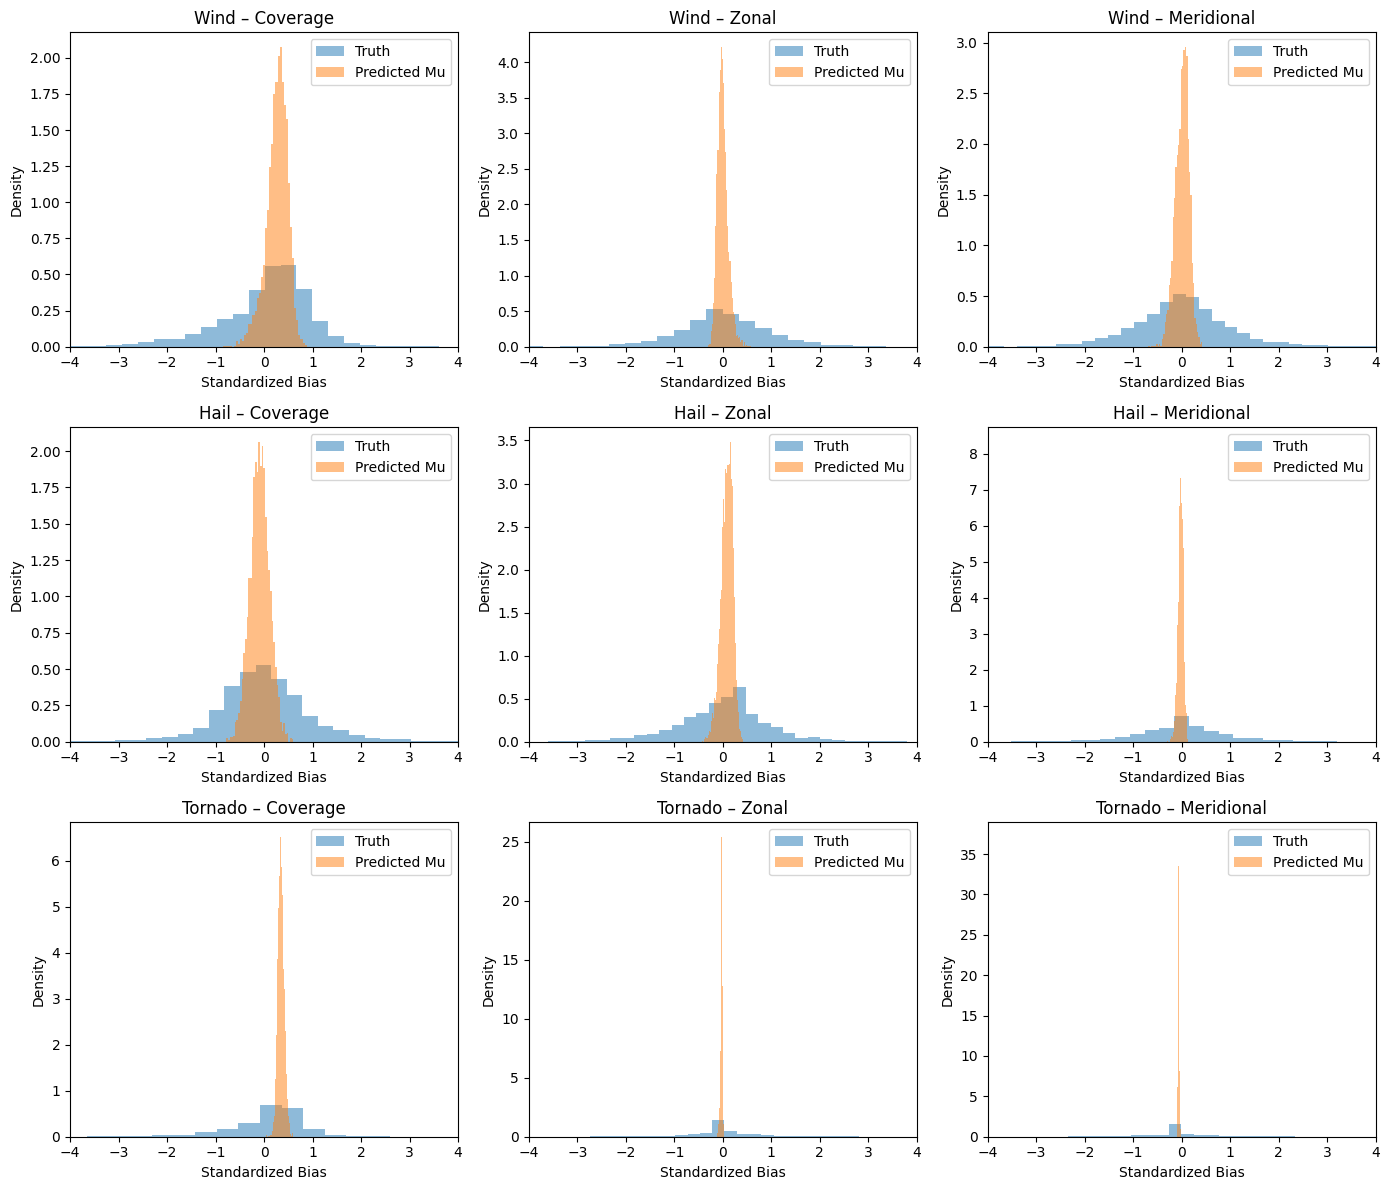

In [7]:
mu = results["mu"].values
truth = results["truth"].values

hazards = ["Wind", "Hail", "Tornado"]
variables = ["Coverage", "Zonal", "Meridional"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j  # flattened index
        
        ax = axes[i, j]
        
        ax.hist(truth[:, k], bins=40, density=True, alpha=0.5, label="Truth")
        ax.hist(mu[:, k], bins=40, density=True, alpha=0.5, label="Predicted Mu")
        ax.set_xlim(-4, 4)
        
        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Standardized Bias")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

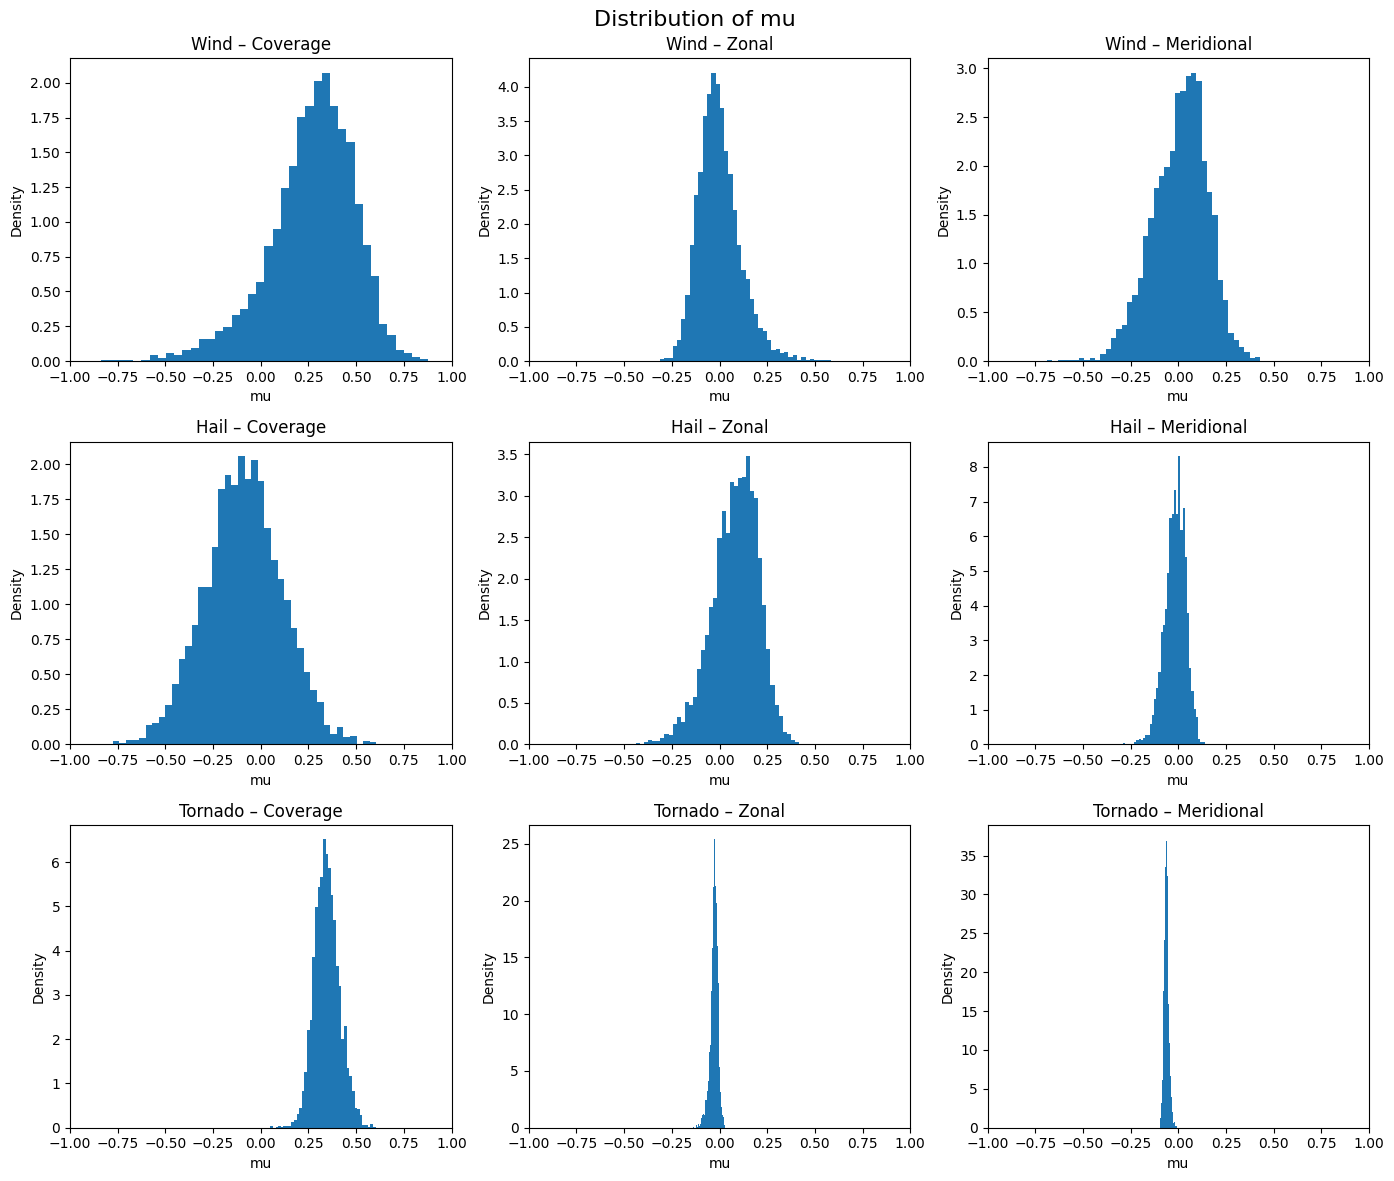

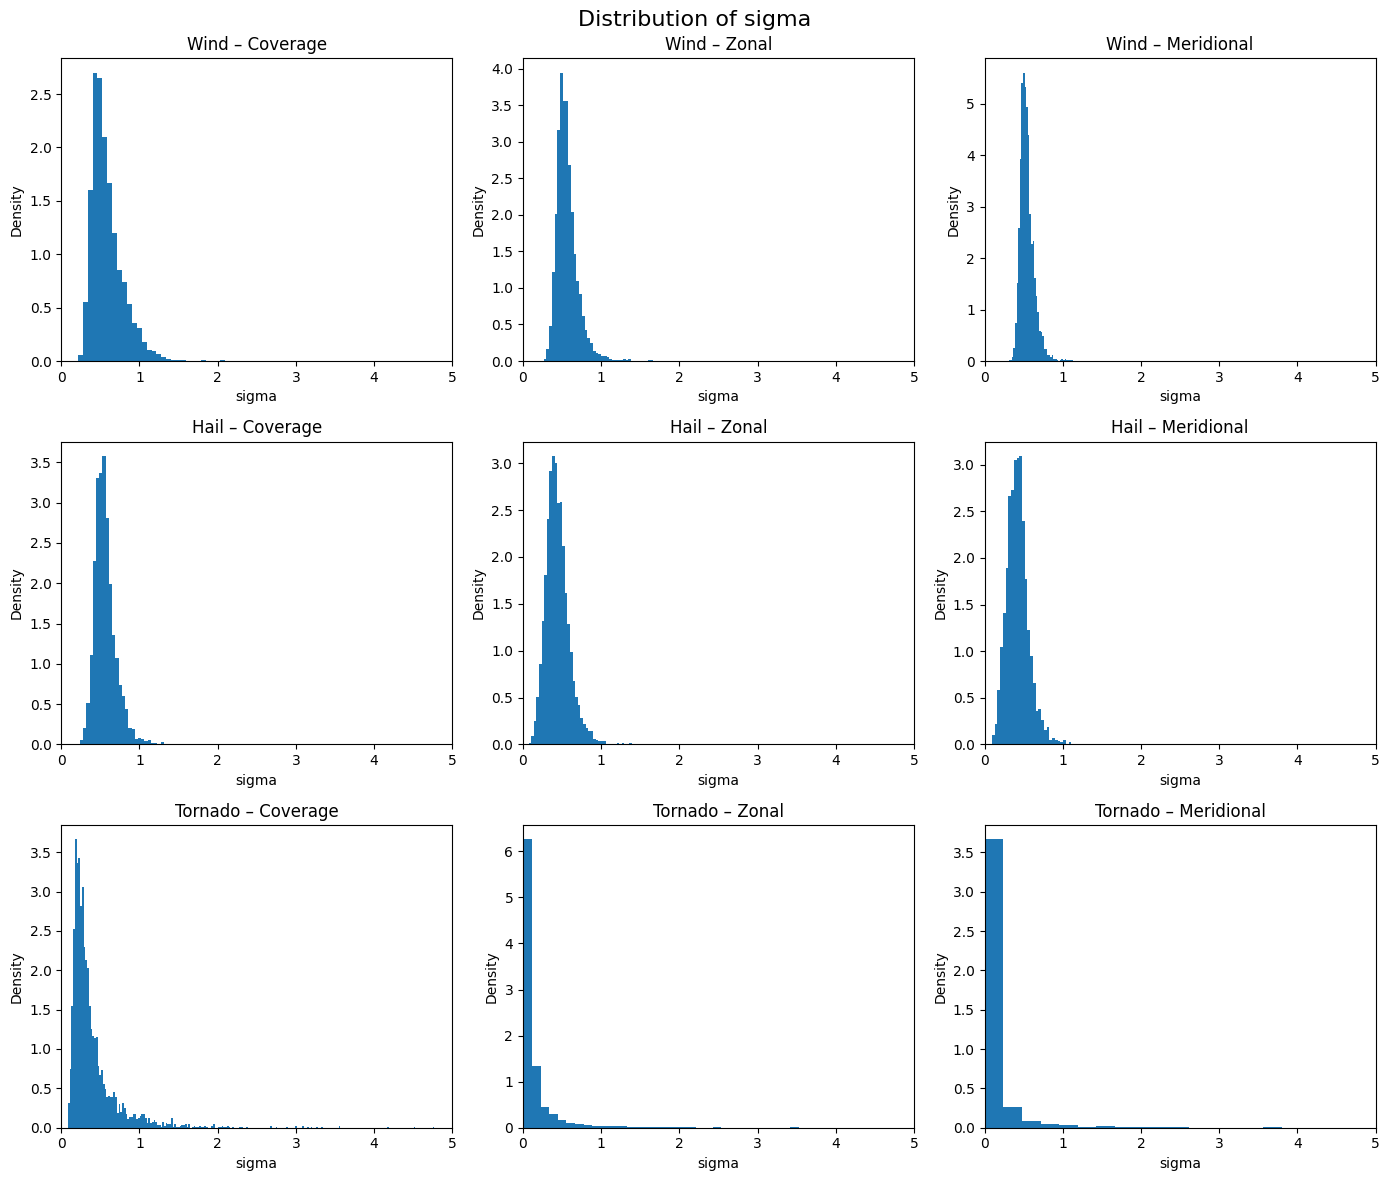

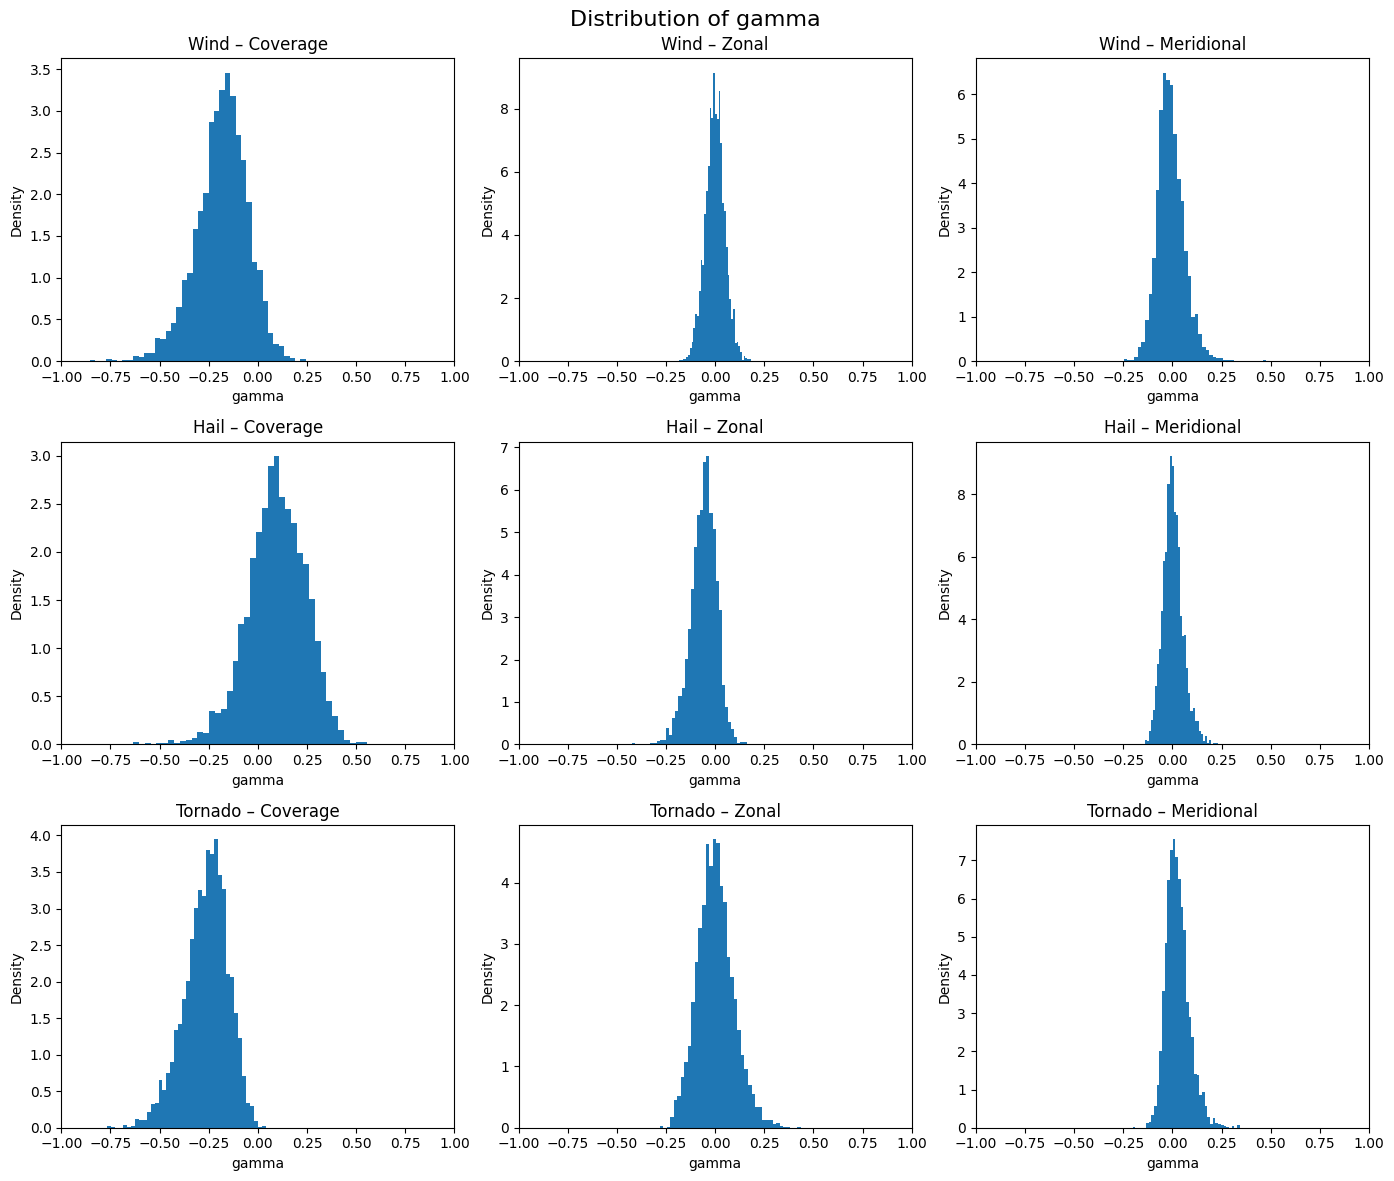

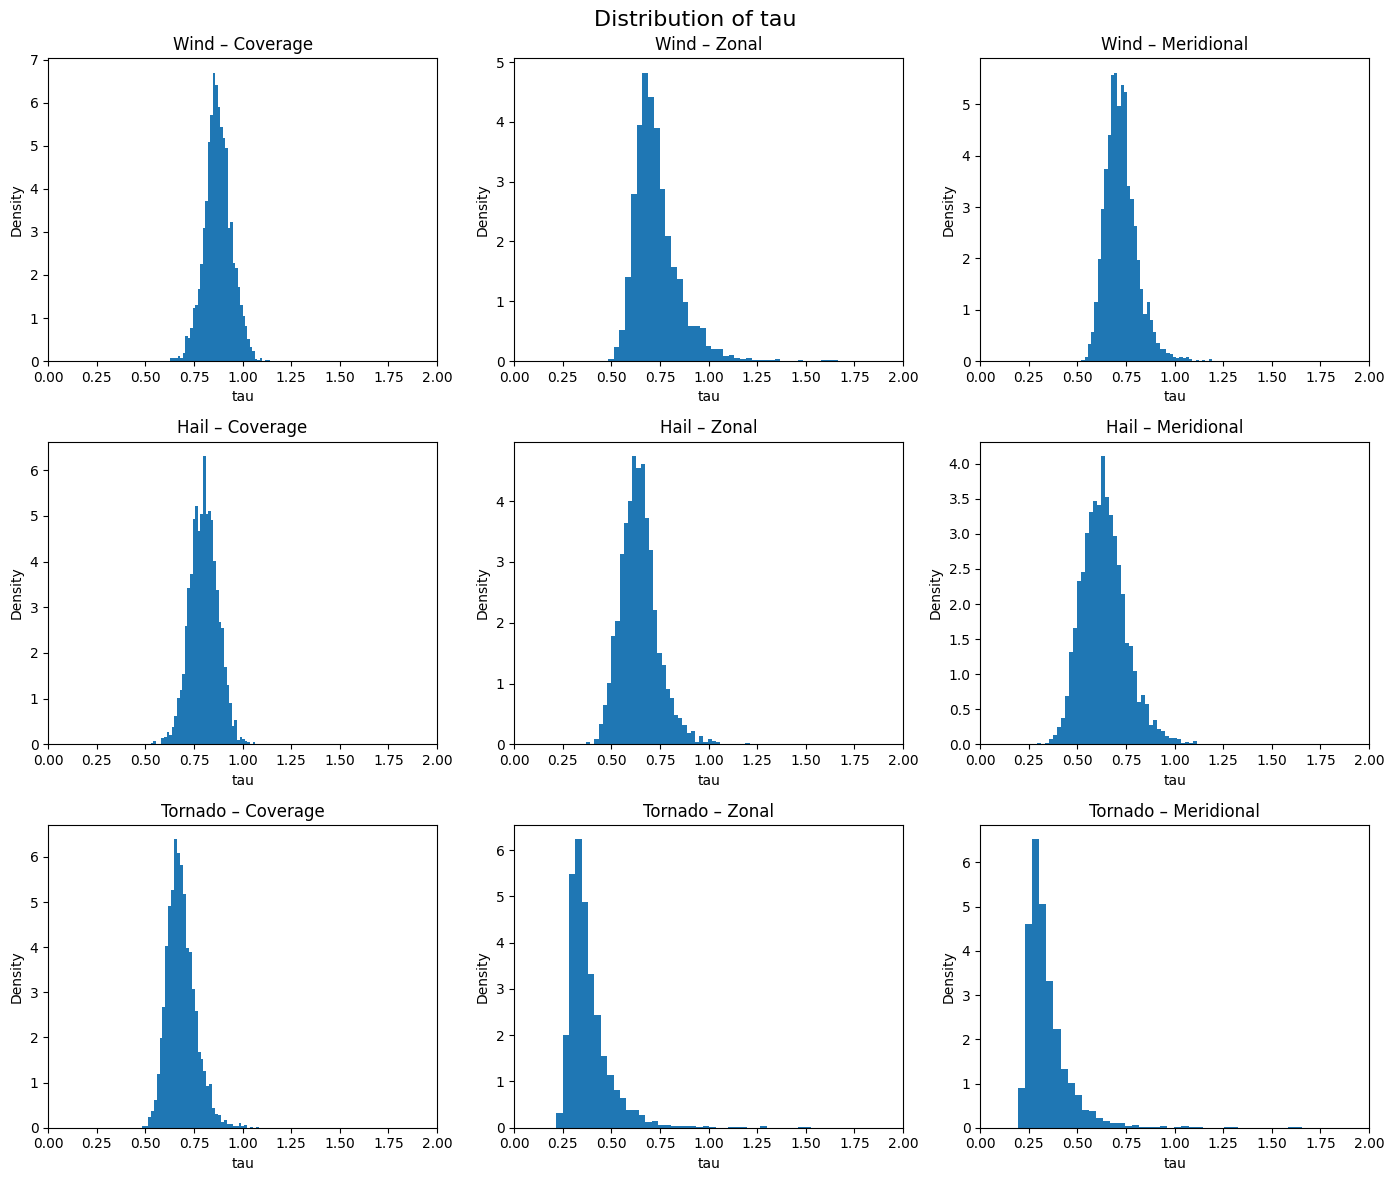

In [8]:
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values

param_dict = {
    "mu": mu,
    "sigma": sigma,
    "gamma": gamma,
    "tau": tau
}

for param_name, values in param_dict.items():
    
    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)
    
    for i, hazard in enumerate(hazards):
        for j, var in enumerate(variables):
            k = i * 3 + j  # flattened index
            bins = 40
            ax = axes[i, j]
            if param_name == 'mu':
                ax.set_xlim(-1, 1)
            elif param_name == 'sigma':
                ax.set_xlim(0, 5)
                if hazard == 'Tornado':
                    bins = 400
            elif param_name == 'gamma':
                ax.set_xlim(-1, 1)
            elif param_name == 'tau':
                ax.set_xlim(0, 2)


            
            ax.hist(values[:, k], bins=bins, density=True)
            
            ax.set_title(f"{hazard} – {var}")
            ax.set_xlabel(param_name)
            ax.set_ylabel("Density")
    
    fig.suptitle(f"Distribution of {param_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

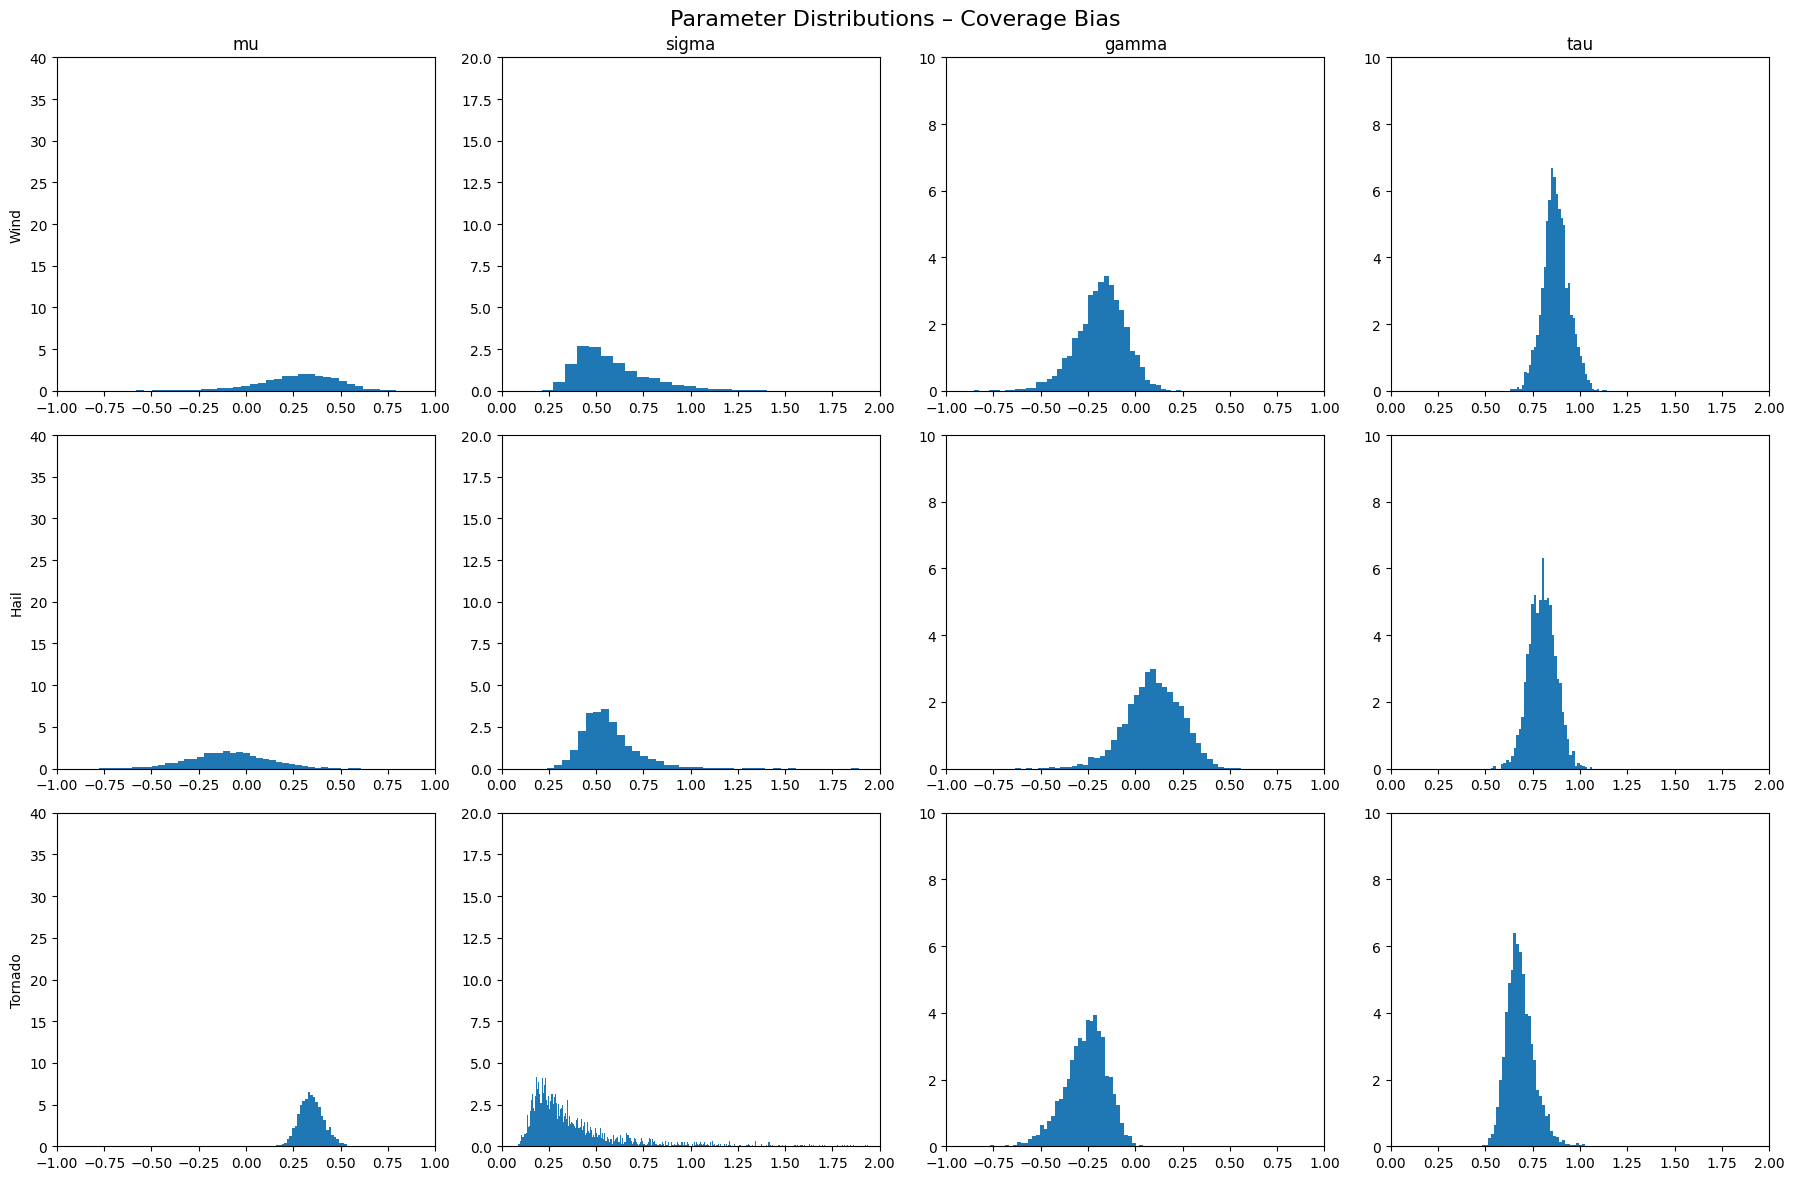

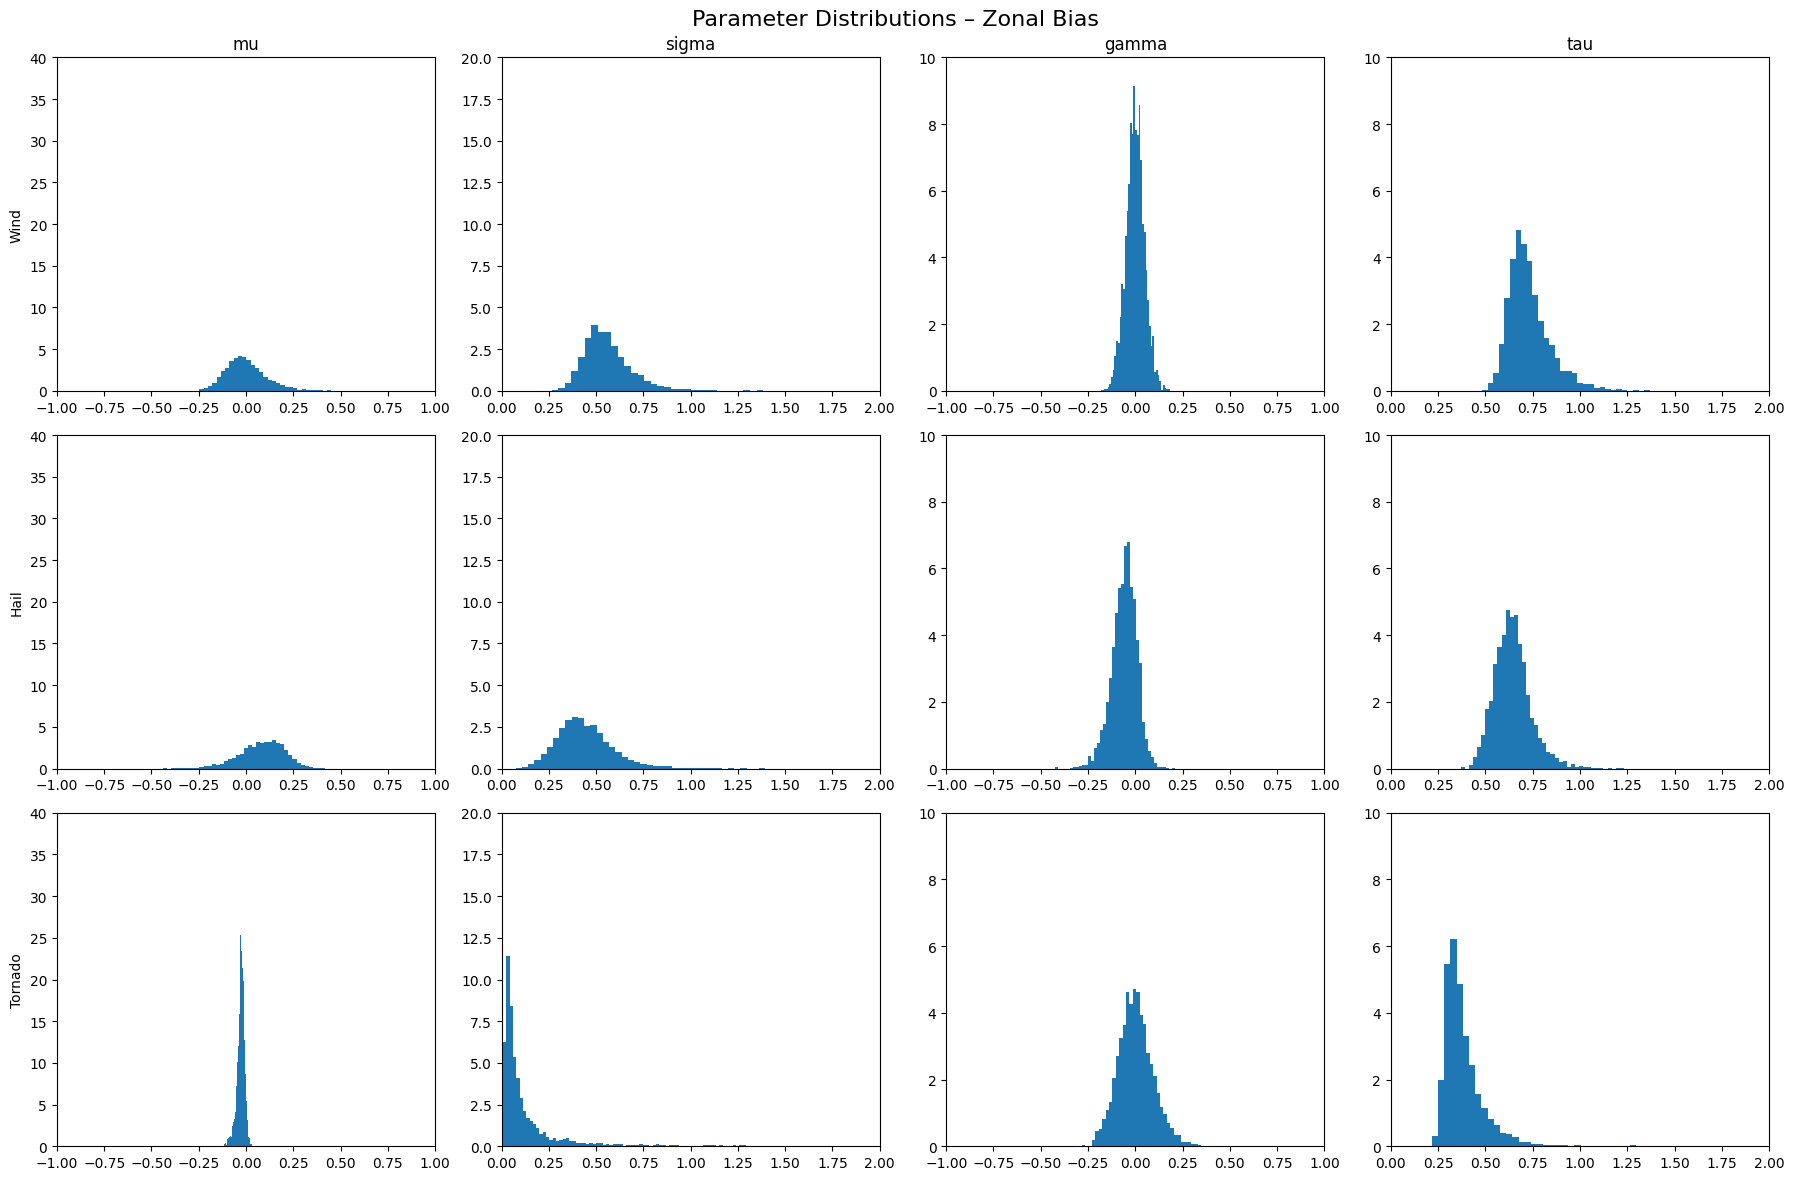

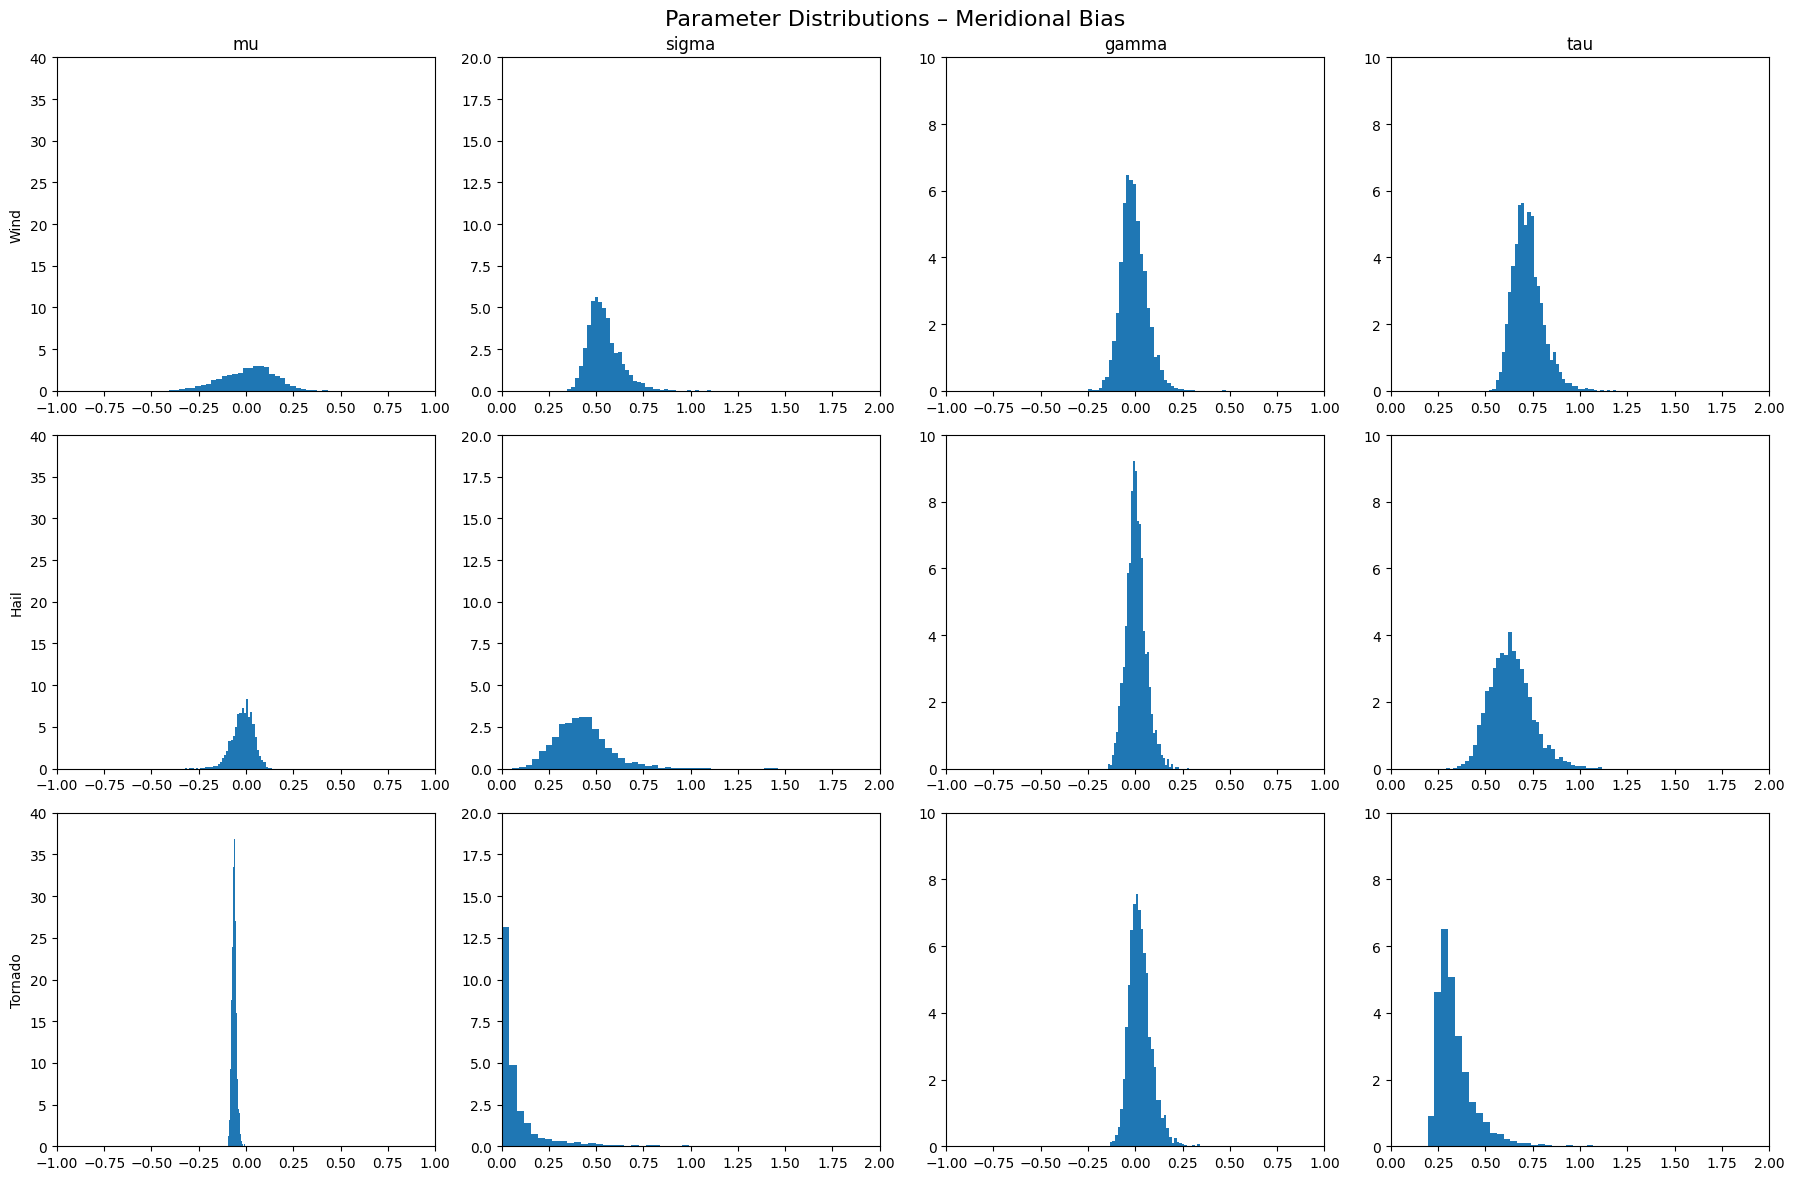

In [9]:
params = ["mu", "sigma", "gamma", "tau"]
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values

param_dict = {
    "mu": mu,
    "sigma": sigma,
    "gamma": gamma,
    "tau": tau
}

for j, var in enumerate(variables):

    fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=False, sharey=False)

    for i, hazard in enumerate(hazards):
        for p, param_name in enumerate(params):

            k = i * 3 + j  # flattened index
            
            ax = axes[i, p]
            values = param_dict[param_name]

            bins = 40

            # Parameter-specific limits
            if param_name == "mu":
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 40)
            elif param_name == "sigma":
                ax.set_xlim(0, 2)
                ax.set_ylim(0, 20)
                if hazard == "Tornado":
                    bins = 2500
            elif param_name == "gamma":
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 10)
            elif param_name == "tau":
                ax.set_xlim(0, 2)
                ax.set_ylim(0, 10)

            ax.hist(values[:, k], bins=bins, density=True)

            if i == 0:
                ax.set_title(param_name)

            if p == 0:
                ax.set_ylabel(hazard)

            #ax.set_xlabel(param_name)

    fig.suptitle(f"Parameter Distributions – {var} Bias", fontsize=16)
    plt.tight_layout()
    plt.show()

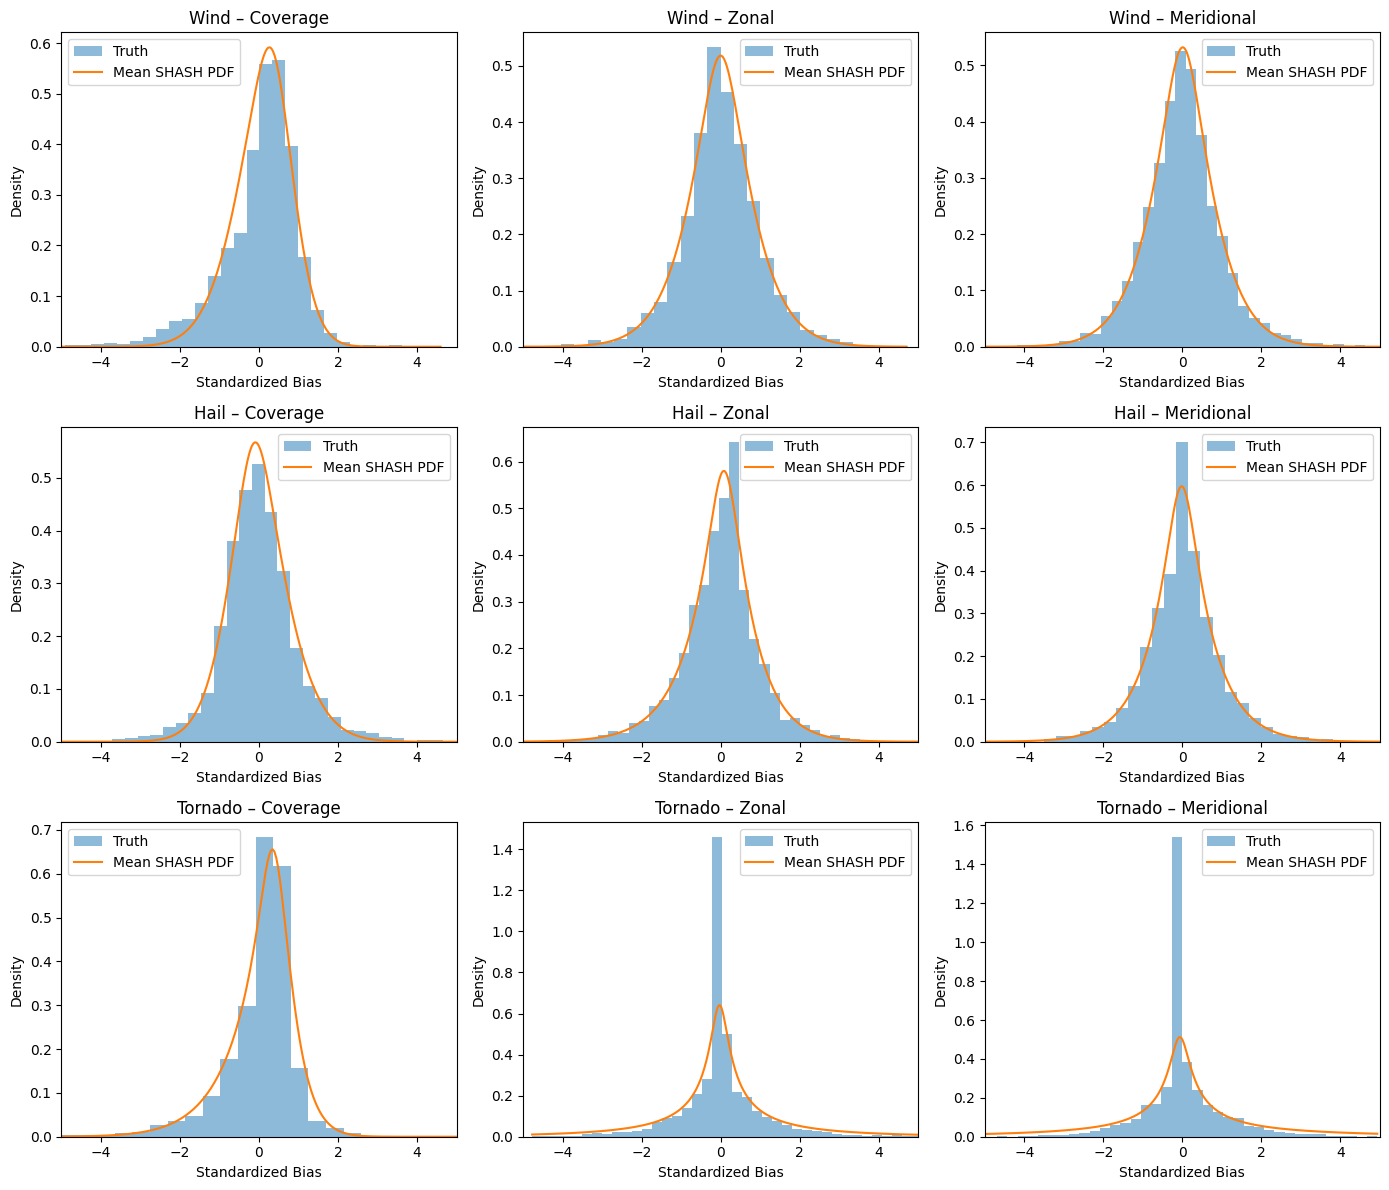

In [10]:
# Extract arrays
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values
truth = results["truth"].values

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j
        
        ax = axes[i, j]
        ax.set_xlim(-5, 5)
        
        # Histogram of truth
        ax.hist(truth[:, k], bins=40, density=True, alpha=0.5, label="Truth")
        
        # Compute mean parameters
        mu_bar = mu[:, k].mean()
        sigma_bar = sigma[:, k].mean()
        gamma_bar = gamma[:, k].mean()
        tau_bar = tau[:, k].mean()
        
        # Build Shash distribution with mean parameters
        params = torch.tensor([[mu_bar, sigma_bar, gamma_bar, tau_bar]])
        dist = Shash(params)
        
        # Create evaluation grid
        x_min = truth[:, k].min()
        x_max = truth[:, k].max()
        x = np.linspace(x_min, x_max, 400)
        
        pdf = dist.prob(torch.tensor(x)).detach().numpy().flatten()
        
        # Overlay PDF
        ax.plot(x, pdf, label="Mean SHASH PDF")
        
        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Standardized Bias")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

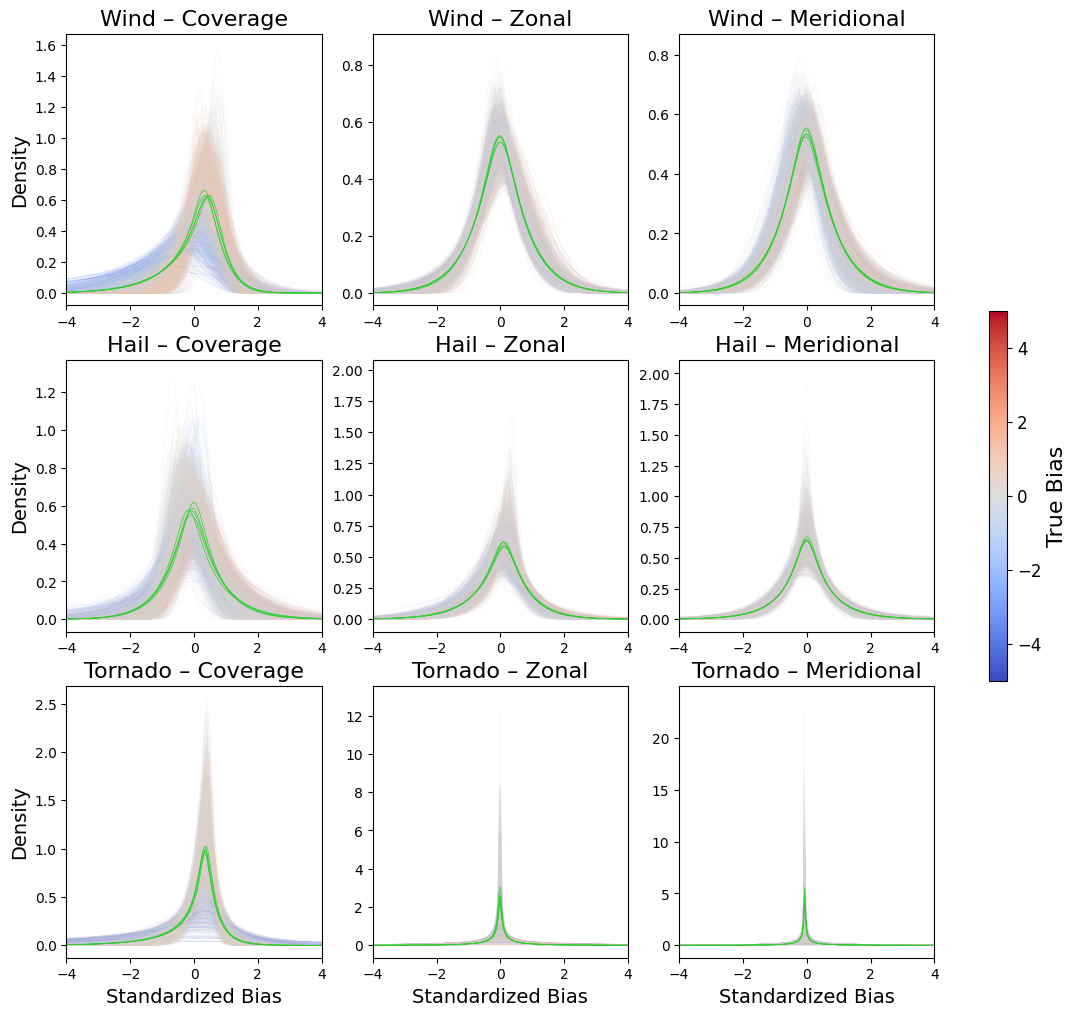

In [21]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Extract arrays
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values
truth = results["truth"].values
baseline_params = torch.load('baseline_shash_params.pt')

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

cmap = cm.get_cmap("coolwarm")
norm = mcolors.Normalize(vmin=-5, vmax=5)

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j
        ax = axes[i, j]
        ax.set_xlim(-4, 4)

        # ax.hist(truth[:, k], bins=40, density=True, alpha=0.3)

        x = np.linspace(-5, 5, 400)
        x_tensor = torch.tensor(x)

        for n in range(mu.shape[0]):
            params = torch.tensor([[mu[n, k],
                                    sigma[n, k],
                                    gamma[n, k],
                                    tau[n, k]]])
            dist = Shash(params)
            pdf = dist.prob(x_tensor).detach().numpy().flatten()

            color = cmap(norm(truth[n, k]))
            ax.plot(x, pdf, color=color, alpha=.5, lw = .1)

        for n in range(5):
            params = baseline_params[n, k, :]
            params[1] = torch.exp(params[1])
            params[3] = torch.exp(params[3])
            dist = Shash(params)
            pdf = dist.prob(x_tensor).detach().numpy().flatten()
            ax.plot(x, pdf, color='limegreen', lw = .5)
        ax.set_title(f"{hazard} – {var}", fontsize=16)
        if hazard == 'Tornado':
            ax.set_xlabel("Standardized Bias", fontsize=14)
        if var == 'Coverage':
            ax.set_ylabel("Density", fontsize=14)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", label="True Bias", shrink=0.4)
cbar.set_label("True Bias", fontsize=16)
cbar.ax.tick_params(labelsize=12)
plt.savefig('figs/distributions/all_pdfs.pdf')
plt.savefig('figs/distributions/all_pdfs.png')
plt.show()


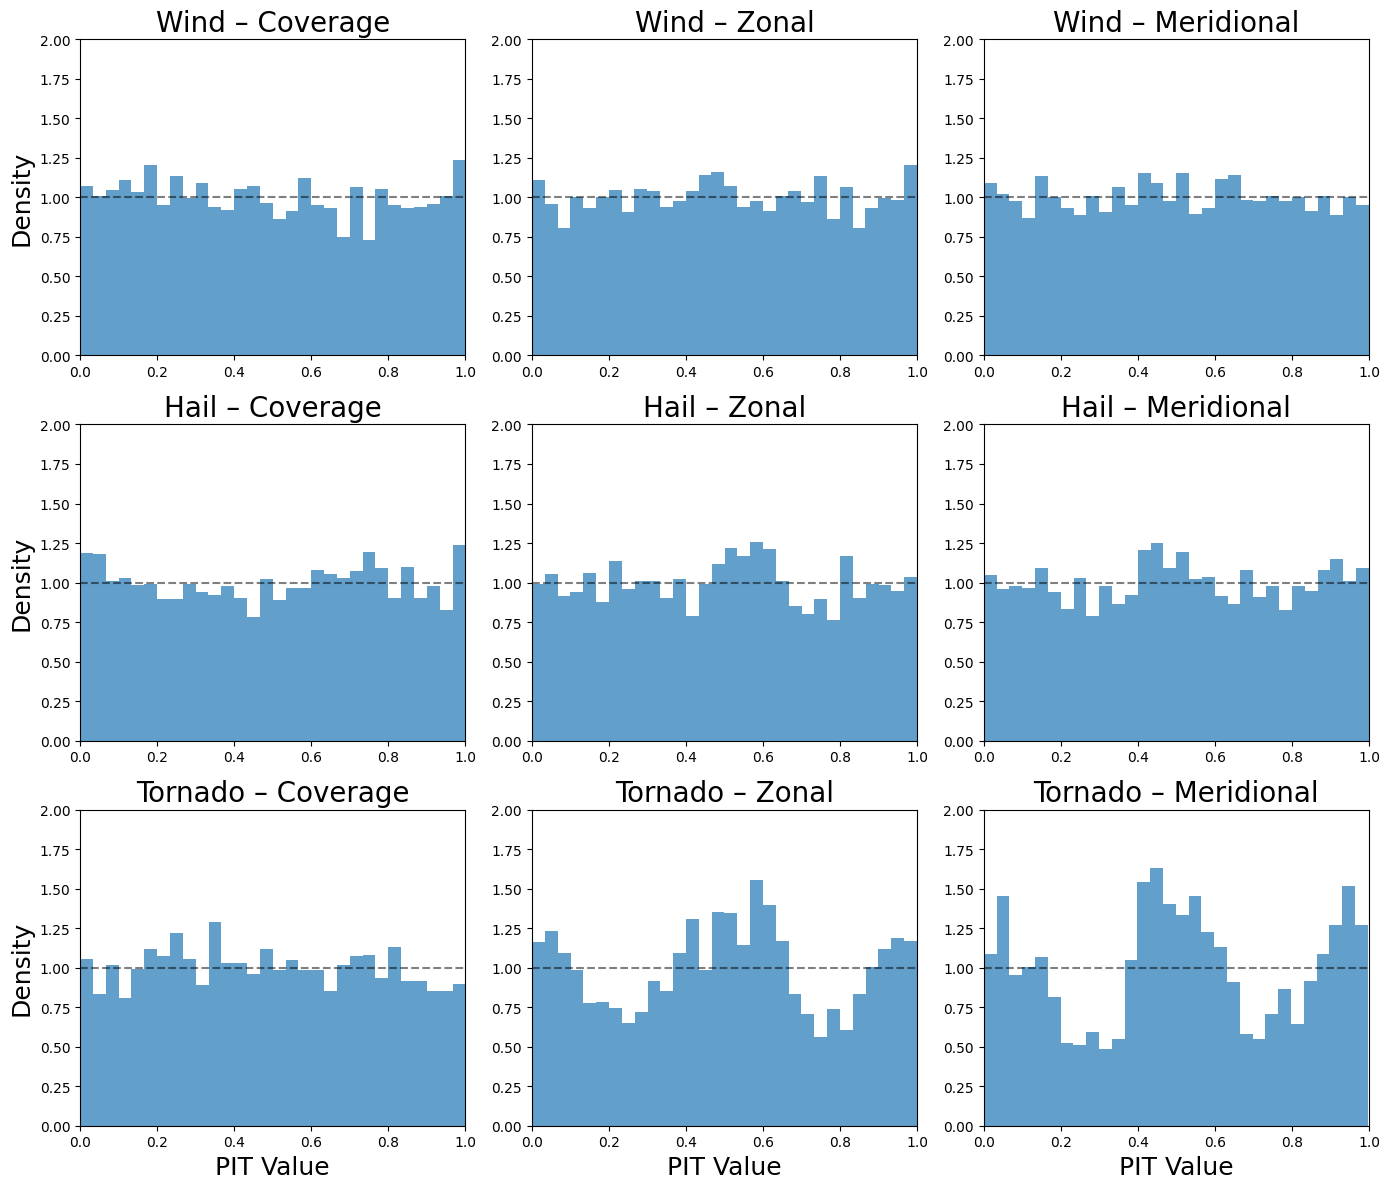

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):

        k = i * 3 + j
        ax = axes[k]

        # Build parameter tensor for SHASH distribution
        params = np.stack([
            mu[:, k],
            sigma[:, k],
            gamma[:, k],
            tau[:, k]
        ], axis=-1)

        shash = Shash(torch.tensor(params))

        # PIT values
        pit_vals = shash.cdf(torch.tensor(truth[:, k])).detach().numpy()

        # Histogram of PIT values
        ax.hist(pit_vals, bins=30, density=True, alpha=0.7)

        ax.plot([0, 1], [1, 1], "k--", alpha=0.5)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 2)
        

        ax.set_title(f"{hazard} – {var}", fontsize=20)
        if hazard == 'Tornado':
            ax.set_xlabel("PIT Value", fontsize=18)
        if var == 'Coverage':
            ax.set_ylabel("Density", fontsize=18)

plt.tight_layout()
plt.savefig('figs/distributions/calibration.pdf')
plt.show()